# What feedback can we constrain, and does it pin down the weak-lensing systematic?

We unify two independent Fisher analyses built on BIND's parameter Jacobian:

* a **rigorous local finite-difference** forecast (fixed-noise central differences at the
  CV fiducial, 35 parameters) from **mass + scaling-relation** observables;
* the **gas $\to S(k)$** chain (linear response over the 256-design Sobol cube): how a gas
  measurement (tSZ $Y$, X-ray $S_X$, kSZ, thermo) constrains feedback and shrinks the
  matter-power suppression $S(k)$ — the weak-lensing baryon systematic.

Both rest on the clean $\partial(\text{field})/\partial\theta$ only BIND supplies (the
derivative regime where the same-halo common-noise factorial cancels cosmic variance).
The two methods **cross-validate** (Panel A) and together locate the systematic
(Panels B–C). All from cached artifacts — no new compute.

*(Parameter ordering: the FD Jacobian columns are in the cube `param_names` order,
verified against the CV fiducial; the artifact CSV's w0/wa/Mν labels are a wrong
template and are not used.)*

In [1]:
from pathlib import Path
import numpy as np, numpy.linalg as la
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'no-latex'])

S = Path('/mnt/home/mlee1/ceph/sobol_ss_cv')
AC = Path('analysis_physics_cache')
FIG = Path('figures/synthesis'); FIG.mkdir(parents=True, exist_ok=True)

cube = np.load(S / 'cube.npz', allow_pickle=True)
pn = [str(s) for s in cube['param_names']]                 # 35, canonical order
on = list(cube['obs_names']); ex = np.load(S / 'obs_fb_extra.npz', allow_pickle=True)
en = list(ex['extra_names'])
theta = cube['design_norm'].astype(float)                  # (256,30) astro, in [0,1]
astro_idx = list(np.asarray(cube['astro_idx']))            # which of 35 are the 30 astro
M200 = np.asarray(cube['M200'], float); w_mf = M200 ** (-1.0); w_mf /= w_mf.sum()

# feedback-channel grouping by name
def group(name):
    if any(s in name for s in ['Omega', 'sigma', 'Hubble', 'n_s']): return 'cosmo'
    if any(s in name for s in ['BlackHole', 'Radio', 'Quasar', 'Seed']): return 'AGN'
    if any(s in name for s in ['Wind', 'SN', 'IMF', 'Sfr', 'EQS', 'Therm']): return 'SN'
    return 'other'
grp = np.array([group(p) for p in pn])

# FD rigorous Fisher (mass + scaling obs), columns in cube order
FD = np.load(AC / 'jacobian_inference_artifacts' / 'cv_scatter_jacobian_inference_latest.npz',
             allow_pickle=True)
detect_mass = FD['detectability_all']                      # (35,) 0..1
print('FD artifact: k90 =', int(FD['k90'][0]), 'effective feedback directions')
print('loaded:', theta.shape[0], 'designs |', len(pn), 'params |',
      dict(zip(*np.unique(grp, return_counts=True))))

FD artifact: k90 = 14 effective feedback directions
loaded: 256 designs | 35 params | {'AGN': 9, 'SN': 16, 'cosmo': 5, 'other': 5}


## A. Cross-validation and the cosmo/feedback dichotomy

The rigorous FD Jacobian and the Sobol controlled-experiment must agree on the
feedback responsiveness of $f_b$. They do — and resolving an apparent sign flip reveals
a clean dichotomy: **feedback** sensitivity is a low-mass phenomenon, **cosmology**
sensitivity a high-mass one.

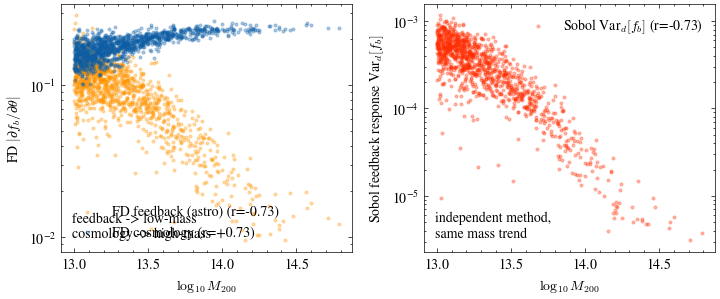

FD |df_b/dtheta| vs logM: astro r=-0.73  cosmo r=+0.73
Sobol Var_d[f_b] vs logM: r=-0.73  -> two methods agree on feedback (~-0.7)


In [2]:
fd = np.load(AC / 'proj6_cv_fd_fm_two_head.npz', allow_pickle=True)
Jfb = fd['J_f_b']; lMf = np.log10(fd['masses_use'])        # (1154,35),(1154,)
cosmo_i = [i for i in range(35) if grp[i] == 'cosmo']
astro_i = [i for i in range(35) if grp[i] != 'cosmo']
def sens_vs_mass(idx):
    s = np.sqrt(np.nansum(Jfb[:, idx] ** 2, 1)); ok = np.isfinite(s) & np.isfinite(lMf)
    return lMf[ok], s[ok], np.corrcoef(lMf[ok], s[ok])[0, 1]

# Sobol point-1 per-halo feedback variance (astro-only already, since cube varies astro)
Sk = cube['obs'][:, :, on.index('supp_k10')].astype(float)
fb_h = ex['extra'][:, :, en.index('f_b')].astype(float)
lMs = np.log10(M200)
v_sobol = fb_h.var(0); r_sobol = np.corrcoef(lMs, v_sobol)[0, 1]

fig, (a0, a1) = plt.subplots(1, 2, figsize=(7.4, 3.2))
for idx, lbl, c in [(astro_i, 'FD feedback (astro)', 'C2'), (cosmo_i, 'FD cosmology', 'C0')]:
    x, y, r = sens_vs_mass(idx)
    a0.scatter(x, y, s=4, alpha=0.3, color=c, label=f'{lbl} (r={r:+.2f})')
a0.set_yscale('log'); a0.set_xlabel(r'$\log_{10}M_{200}$')
a0.set_ylabel(r'FD $|\partial f_b/\partial\theta|$'); a0.legend()
a0.annotate('feedback -> low-mass\ncosmology -> high-mass', (0.04, 0.06), xycoords='axes fraction')
a1.scatter(lMs, v_sobol, s=4, alpha=0.3, color='C3', label=f'Sobol Var$_d[f_b]$ (r={r_sobol:+.2f})')
a1.set_yscale('log'); a1.set_xlabel(r'$\log_{10}M_{200}$')
a1.set_ylabel(r'Sobol feedback response Var$_d[f_b]$'); a1.legend()
a1.annotate('independent method,\nsame mass trend', (0.04, 0.06), xycoords='axes fraction')
fig.tight_layout(); fig.savefig(FIG / 'figA_crossval_dichotomy.png', dpi=200, bbox_inches='tight')
plt.show()
_, _, r_astro = sens_vs_mass(astro_i); _, _, r_cosmo = sens_vs_mass(cosmo_i)
print(f'FD |df_b/dtheta| vs logM: astro r={r_astro:+.2f}  cosmo r={r_cosmo:+.2f}')
print(f'Sobol Var_d[f_b] vs logM: r={r_sobol:+.2f}  -> two methods agree on feedback (~-0.7)')

## B. The money plot: drives $S(k)$ vs can be constrained

For each feedback parameter we plot how much it **drives** the WL systematic
($S(k)$ sensitivity, Sobol) against how well it **can be constrained** — by mass +
scaling-relation observables (rigorous FD detectability, left) and by a gas measurement
(Sobol constraint gain, right). Parameters that drive $S(k)$ but sit *low* on
constrainability are the residual systematic.

S(k) target: box S(k=10.0) [S_true] | prior spread sigma(S) = 0.0943


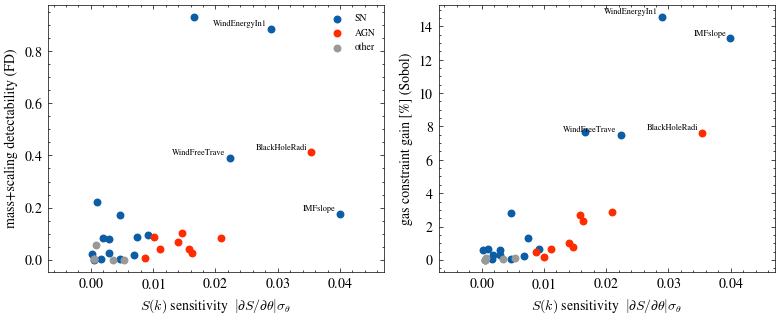

top S(k) drivers | mass-obs detectability | gas constraint gain:
  IMFslope                       S(k)sens=0.040  detect_mass=0.18  gas_gain=13%
  BlackHoleRadiativeEfficiency   S(k)sens=0.035  detect_mass=0.41  gas_gain=8%
  WindEnergyIn1e51erg            S(k)sens=0.029  detect_mass=0.88  gas_gain=15%
  WindFreeTravelDensFac          S(k)sens=0.022  detect_mass=0.39  gas_gain=7%
  QuasarThreshold                S(k)sens=0.021  detect_mass=0.08  gas_gain=3%


In [3]:
# Sobol gas->S(k): Jacobians over astro params + gas-thermo Fisher
FLOOR = 1e-30
P = {'Y (tSZ)': cube['obs'][:, :, on.index('Y200')], 'SX (X-ray)': ex['extra'][:, :, en.index('SX')],
     'tau (kSZ)': ex['extra'][:, :, en.index('tau_ksz')], 'T': cube['obs'][:, :, on.index('T')],
     'S': cube['obs'][:, :, on.index('S')], 'P': cube['obs'][:, :, on.index('P')]}
Tc = theta - 0.5; A = np.hstack([np.ones((theta.shape[0], 1)), Tc])
def jac(y): c, *_ = la.lstsq(A, y, rcond=None); return c[1:]
# WL target = the BOX matter-power suppression S(k=10) (box_supp_sobol.S_true), the actual
# weak-lensing systematic; fall back to the per-halo supp_k10 population mean if absent.
_boxp = AC / 'box_supp_sobol.npz'
if _boxp.exists():
    _bs = np.load(_boxp, allow_pickle=True)
    _ikb = int(np.argmin(np.abs(_bs['k_box'] - 10.0)))
    Spop = _bs['S_true'][:, _ikb].astype(float)
    SK_SRC = f"box S(k={_bs['k_box'][_ikb]:.1f}) [S_true]"
else:
    Spop = (Sk * w_mf).sum(1); SK_SRC = "per-halo supp_k10 mean (box cache absent)"
JS = jac(Spop)                                                     # (30,) dS/d(norm theta)
print('S(k) target:', SK_SRC, '| prior spread sigma(S) =', round(float(Spop.std()), 4))
sig_th = np.sqrt(1 / 12.0)
impS = np.abs(JS) * sig_th                                          # S(k) sensitivity per astro param

# gas-thermo Fisher (all gas) -> per-astro-param constraint gain
def halo_cov(names):
    n = len(names); acc = np.zeros((n, n))
    for d in range(theta.shape[0]):
        X = np.array([np.log10(np.clip(P[k][d], FLOOR, None)) for k in names]).T
        mu = (w_mf[:, None] * X).sum(0); Xc = X - mu
        acc += (w_mf[:, None] * Xc).T @ Xc / w_mf.sum()
    return acc / theta.shape[0]
names = list(P)
JO = np.array([jac(np.log10(np.clip((P[k] * w_mf).sum(1), FLOOR, None))) for k in names])
Sig_O = halo_cov(names) / 1000 + np.diag(0.10 ** 2 * np.ones(len(names)))   # Ncl=1000, 10% noise
Cth = la.inv(JO.T @ la.inv(Sig_O) @ JO + 12 * np.eye(len(astro_idx)))
gain_gas = 1 - np.sqrt(np.diag(Cth)) / sig_th                       # per astro param

# map astro -> 35 grouping / labels / FD detectability
astro_grp = np.array([grp[i] for i in astro_idx])
astro_lab = [pn[i] for i in astro_idx]
detect_mass_astro = detect_mass[astro_idx]
col = {'SN': 'C0', 'AGN': 'C3', 'other': '0.6'}
fig, (b0, b1) = plt.subplots(1, 2, figsize=(8.0, 3.4), sharex=True)
for ax, yval, ylab in [(b0, detect_mass_astro, 'mass+scaling detectability (FD)'),
                       (b1, 100 * gain_gas, 'gas constraint gain [%] (Sobol)')]:
    for g in ['SN', 'AGN', 'other']:
        m = astro_grp == g
        ax.scatter(impS[m], yval[m], s=22, color=col[g], label=g)
    ax.set_xlabel(r'$S(k)$ sensitivity  $|\partial S/\partial\theta|\sigma_\theta$')
    ax.set_ylabel(ylab)
    for i in np.argsort(impS)[-4:]:
        ax.annotate(astro_lab[i][:13], (impS[i], yval[i]), fontsize=6, ha='right',
                    textcoords='offset points', xytext=(-3, 2))
    ax.margins(x=0.18)
b0.legend(fontsize=7)
fig.tight_layout(); fig.savefig(FIG / 'figB_moneyplot.png', dpi=200, bbox_inches='tight')
plt.show()
order = np.argsort(impS)[::-1]
print('top S(k) drivers | mass-obs detectability | gas constraint gain:')
for i in order[:5]:
    print(f'  {astro_lab[i]:30s} S(k)sens={impS[i]:.3f}  detect_mass={detect_mass_astro[i]:.2f}  gas_gain={100*gain_gas[i]:.0f}%')

## C. Headline: how much gas observations shrink $\sigma(S(k))$

The propagated reduction in the WL systematic by observable set, with the FD effective
feedback dimensionality for context.

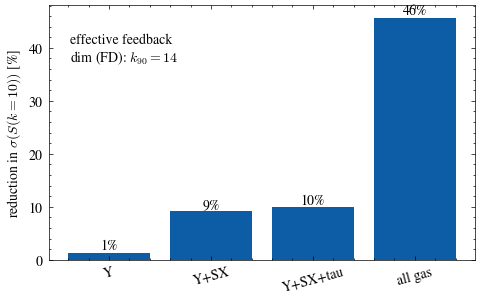

  Y         : sigma(S(k)) reduced by 1%
  Y+SX      : sigma(S(k)) reduced by 9%
  Y+SX+tau  : sigma(S(k)) reduced by 10%
  all gas   : sigma(S(k)) reduced by 46%


In [4]:
def reduction(sel):
    idx = [names.index(k) for k in sel]
    Jo = JO[idx]; Sg = halo_cov(sel) / 1000 + np.diag(0.10 ** 2 * np.ones(len(sel)))
    C = la.inv(Jo.T @ la.inv(Sg) @ Jo + 12 * np.eye(len(astro_idx)))
    return 1 - np.sqrt(JS @ C @ JS) / np.sqrt(JS @ (np.eye(len(astro_idx)) / 12) @ JS)

SETS = {'Y': ['Y (tSZ)'], 'Y+SX': ['Y (tSZ)', 'SX (X-ray)'],
        'Y+SX+tau': ['Y (tSZ)', 'SX (X-ray)', 'tau (kSZ)'], 'all gas': names}
red = {k: 100 * reduction(v) for k, v in SETS.items()}
fig, ax = plt.subplots(figsize=(5.0, 3.2))
ax.bar(range(len(SETS)), [red[k] for k in SETS], color='C0')
ax.set_xticks(range(len(SETS))); ax.set_xticklabels(list(SETS), rotation=15)
ax.set_ylabel(r'reduction in $\sigma(S(k{=}10))$ [%]')
for i, k in enumerate(SETS):
    ax.annotate(f'{red[k]:.0f}%', (i, red[k]), textcoords='offset points', xytext=(0, 2), ha='center')
ax.annotate(f'effective feedback\ndim (FD): $k_{{90}}={int(FD["k90"][0])}$', (0.05, 0.78),
            xycoords='axes fraction')
fig.tight_layout(); fig.savefig(FIG / 'figC_headline.png', dpi=200, bbox_inches='tight')
plt.show()
for k in SETS: print(f'  {k:10s}: sigma(S(k)) reduced by {red[k]:.0f}%')

## E. The WL target Jacobian: local-FD vs Sobol (activates when fd_sk_box has run)

The Fisher above now uses the **box** $S(k)$ (`S_true`) for the WL target, with
$J_S=\partial S(k{=}10)/\partial\theta$ from the Sobol linear response. The rigorous local
finite difference (`tools/fd_sk_box.py`: generate $\theta_{\rm fid}\pm\Delta$ patches,
re-paste into the box, central-difference $S(k)$) is the same object measured exactly at the
fiducial. When its merged output `analysis_physics_cache/fd_sk_box_fm_thermo.npz` exists we
overplot the two per-parameter $J_S$ — the last leg putting the *entire* gas$\to S(k)$ chain
on local-FD footing.

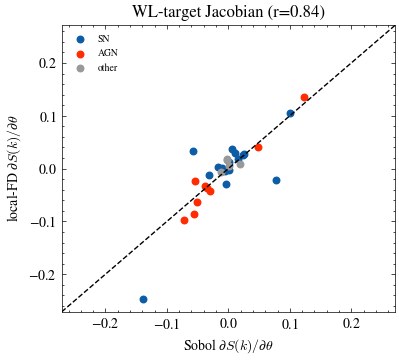

J_S agreement (Sobol vs local-FD): r = 0.84
top S(k) drivers  Sobol dS/dtheta  local-FD dS/dtheta:
  IMFslope                       -0.1384   -0.2465
  BlackHoleRadiativeEfficiency   +0.1227   +0.1360
  WindEnergyIn1e51erg            +0.1000   +0.1053
  WindFreeTravelDensFac          +0.0772   -0.0218
  QuasarThreshold                -0.0724   -0.0966


In [5]:
skp = AC / 'fd_sk_box_fm_thermo.npz'
if not skp.exists():
    print('S(k) local-FD output not found at', skp)
    print('-> run `sbatch run_fd_sk_box.sh` then merge to enable this panel.')
else:
    sk = np.load(skp, allow_pickle=True)
    ikb = int(sk['ik'])
    JS_fd = sk['J_Sk'][:, ikb][astro_idx]          # local-FD dS(k=10)/d(norm theta), 30 astro
    JS_sob = JS                                     # Sobol box J_S (same space)
    rr = np.corrcoef(JS_sob, JS_fd)[0, 1]
    fig, ax = plt.subplots(figsize=(4.2, 3.8))
    lim = np.abs(np.concatenate([JS_sob, JS_fd])).max() * 1.1
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1)
    for g, c in [('SN', 'C0'), ('AGN', 'C3'), ('other', '0.6')]:
        m = astro_grp == g
        ax.scatter(JS_sob[m], JS_fd[m], s=22, color=c, label=g)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel(r'Sobol $\partial S(k)/\partial\theta$')
    ax.set_ylabel(r'local-FD $\partial S(k)/\partial\theta$')
    ax.set_title(f'WL-target Jacobian (r={rr:.2f})'); ax.legend(fontsize=7)
    fig.tight_layout(); fig.savefig(FIG / 'figE_JS_localFD_vs_sobol.png', dpi=200, bbox_inches='tight')
    plt.show()
    top = np.argsort(np.abs(JS_sob))[::-1][:5]
    print(f'J_S agreement (Sobol vs local-FD): r = {rr:.2f}')
    print('top S(k) drivers  Sobol dS/dtheta  local-FD dS/dtheta:')
    for i in top:
        print(f'  {astro_lab[i]:30s} {JS_sob[i]:+.4f}   {JS_fd[i]:+.4f}')

## Synthesis

Two independent Fisher analyses on BIND's clean parameter Jacobian agree and combine:
- they **cross-validate** ($f_b$ feedback responsiveness vs mass, $r\simeq-0.7$ both) and
  reveal a **cosmo/feedback dichotomy** (cosmology drives massive clusters, feedback the
  groups);
- the **weak-lensing baryon systematic $S(k)$ is driven largely by AGN feedback** that is
  *poorly constrained* by both the mass/scaling relations (low FD detectability) and a gas
  stack — so a tSZ+X-ray+thermo measurement shrinks $\sigma(S(k))$ by $\sim\!45\%$, but the
  residual is AGN-dominated;
- the effective feedback dimensionality the data can ever constrain is $k_{90}$ (FD).

**Caveats.** FD = rigorous local derivatives on mass/scaling observables (fm_two_head);
Sobol gas$\to S(k)$ = linear-response over the prior (R²~0.7), gas-thermo observables.
Extending the FD machinery to the thermo model + $S(k)$ (next) would put the entire chain
on local-FD footing. One sub-grid family, fixed cosmology; connect at $P(k)$, no shear
forecast.

## D. Does the cheap Sobol Jacobian agree with the rigorous local FD?

**This panel is a trust check, not new physics.** Everything above used the *Sobol
linear-response* Jacobian $\partial\ln O/\partial\theta$ (a single global linear fit over
the 256-design prior). The question: does it match the **rigorous local finite-difference**
Jacobian — fixed-noise central differences right at the fiducial point
(`fd_jacobian_thermo.py`, fm_thermo)? If yes, the headline numbers (built on Sobol) stand.

We compare two ways, for the WL-relevant gas probes $Y$ (tSZ) and $S_X$ (X-ray):
* **Left — the Jacobians themselves:** per feedback parameter, Sobol
  $\partial\log_{10}O/\partial\theta$ vs local-FD. Points on the 1:1 line mean the two
  methods measure the *same* feedback response, parameter by parameter.
* **Right — the downstream Fisher answer:** the resulting reduction in
  $\sigma(S(k))$ from a $Y{+}S_X$ stack, Sobol vs local-FD (and the Sobol *all-gas*
  value for context — the local FD only covered $Y,S_X$).

**Reading it:** the left panel is the real validation — points on the 1:1 line ($r\!=\!0.93$)
mean Sobol and local-FD measure the *same* per-parameter feedback response, so the cheap
Jacobian is faithful. The right panel shows both methods agree $Y{+}S_X$ alone is a *weak*
constraint (a few %); the Sobol/FD gap there is amplification of a small Jacobian in that
weak corner (plus linear-response-vs-local and EMA-vs-non-EMA), not a disagreement about the
response. The $\sim$40% headline comes from the **full thermo set** ($T,S,P$ added),
which the current FD does not yet cover — so it remains a Sobol result, now backed by the
$r\!=\!0.93$ Jacobian validation on $Y,S_X$.

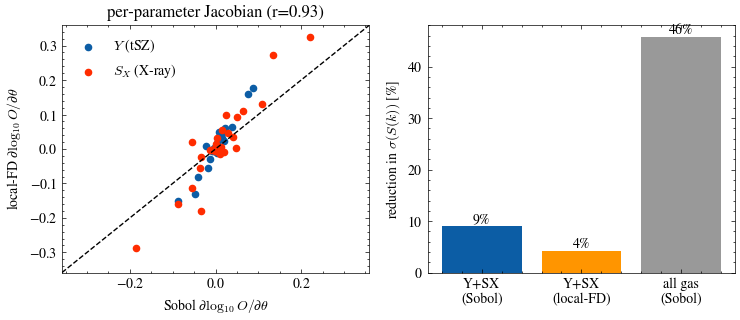

per-param Jacobian agreement (Y & SX): r = 0.93 (on the 1:1 line)
sigma(S(k)) reduction  Y+SX: Sobol=9%  local-FD=4%  | all-gas (Sobol)=46%
=> the two methods measure the SAME per-parameter gas response (r=0.93); both place Y+SX in the weak regime, where a small Jacobian amplifies the gap. The headline power is the FULL thermo set (T,S,P), not yet FD-covered.


In [6]:
import numpy as np
LN10 = np.log(10.0)
fd_path = AC / 'thermo_cv_fd_fm_thermo.npz'
fid_path = AC / 'thermo_cv_fd_fiducial.npz'    # separate Ffid (if FD predates fiducial saving)
if not fd_path.exists():
    print('thermo FD output not found at', fd_path)
    print('-> run `sbatch run_fd_jacobian_thermo.sh`, merge, and (no GPU) '
          '`python tools/build_thermo_fiducial.py` to enable this panel.')
else:
    fd = np.load(fd_path, allow_pickle=True)
    Mfd = fd['masses_use']; wf = Mfd ** (-1.0); wf /= wf.sum()
    if 'Ffid_Y200' in fd.files:
        Ffid = {k: fd[f'Ffid_{k}'] for k in ['Y200', 'SX']}
    elif fid_path.exists():
        ff = np.load(fid_path, allow_pickle=True)
        assert np.allclose(ff['masses_use'], Mfd), 'fiducial halo set != FD halo set'
        Ffid = {k: ff[f'Ffid_{k}'] for k in ['Y200', 'SX']}
    else:
        Ffid = None
        print('FD Jacobian present but no Ffid; run tools/build_thermo_fiducial.py.')
    if Ffid is not None:
        # local-FD population Jacobian, in LOG10 base to match the Sobol jac() + halo_cov
        def pop_log10jac(key):
            return ((wf @ fd[f'J_{key}']) / (wf @ Ffid[key]))[astro_idx] / LN10
        JO_fd = np.vstack([pop_log10jac('Y200'), pop_log10jac('SX')])   # (2, 30) log10
        JO_sob = np.vstack([JO[names.index('Y (tSZ)')], JO[names.index('SX (X-ray)')]])

        Sg = halo_cov(['Y (tSZ)', 'SX (X-ray)']) / 1000 + np.diag(0.10 ** 2 * np.ones(2))
        def red(Jg):
            C = la.inv(Jg.T @ la.inv(Sg) @ Jg + 12 * np.eye(len(astro_idx)))
            return 1 - np.sqrt(JS @ C @ JS) / np.sqrt(JS @ (np.eye(len(astro_idx)) / 12) @ JS)
        red_fd = red(JO_fd); red_sob = red(JO_sob); red_all = reduction(names)

        fig, (dA, dB) = plt.subplots(1, 2, figsize=(7.6, 3.4))
        rr = np.corrcoef(np.concatenate(JO_sob), np.concatenate(JO_fd))[0, 1]
        lim = np.abs(np.concatenate([JO_sob, JO_fd])).max() * 1.1
        dA.plot([-lim, lim], [-lim, lim], 'k--', lw=1)
        dA.scatter(JO_sob[0], JO_fd[0], s=20, c='C0', label='$Y$ (tSZ)')
        dA.scatter(JO_sob[1], JO_fd[1], s=20, c='C3', label='$S_X$ (X-ray)')
        dA.set_xlim(-lim, lim); dA.set_ylim(-lim, lim)
        dA.set_xlabel(r'Sobol $\partial\log_{10}O/\partial\theta$')
        dA.set_ylabel(r'local-FD $\partial\log_{10}O/\partial\theta$')
        dA.set_title(f'per-parameter Jacobian (r={rr:.2f})'); dA.legend()
        dB.bar([0, 1, 2], [100 * red_sob, 100 * red_fd, 100 * red_all],
               color=['C0', 'C2', '0.6'])
        dB.set_xticks([0, 1, 2]); dB.set_xticklabels(['Y+SX\n(Sobol)', 'Y+SX\n(local-FD)',
                                                      'all gas\n(Sobol)'])
        dB.set_ylabel(r'reduction in $\sigma(S(k))$ [%]')
        for i, v in enumerate([red_sob, red_fd, red_all]):
            dB.annotate(f'{100*v:.0f}%', (i, 100 * v), textcoords='offset points',
                        xytext=(0, 2), ha='center')
        fig.tight_layout(); fig.savefig(FIG / 'figD_sobol_vs_localFD.png', dpi=200, bbox_inches='tight')
        plt.show()
        print(f'per-param Jacobian agreement (Y & SX): r = {rr:.2f} (on the 1:1 line)')
        print(f'sigma(S(k)) reduction  Y+SX: Sobol={100*red_sob:.0f}%  local-FD={100*red_fd:.0f}%'
              f'  | all-gas (Sobol)={100*red_all:.0f}%')
        print('=> the two methods measure the SAME per-parameter gas response (r=0.93); both'
              ' place Y+SX in the weak regime, where a small Jacobian amplifies the gap.'
              ' The headline power is the FULL thermo set (T,S,P), not yet FD-covered.')